---
title: Quantum approximate optimization algorithm
description: Solve max-cut using QAOA with a Qiskit pattern at utility scale.
---

{/* cspell:ignore frameon popcount fval */}

# Quantum approximate optimization algorithm

*Usage estimate: 22 minutes on a Heron r3 processor (NOTE: This is an estimate only. Your runtime might vary.)*



## Learning outcomes

After completing this tutorial, you can expect to understand the following information:

* How to map a classical combinatorial optimization problem (max-cut) to a quantum Hamiltonian
* How to implement and run the Quantum Approximate Optimization Algorithm (QAOA) using IBM Quantum Compute Service sessions
* How to scale a QAOA workflow from a small simulator example to utility-scale hardware execution

## Prerequisites

It is recommended that you familiarize yourself with these topics:

* [Basics of quantum circuits](/learning/courses/basics-of-quantum-information)
* [Variational algorithms](/learning/courses/variational-algorithm-design)
* [QAOA in depth](/learning/courses/quantum-computing-in-practice/utility-scale-qaoa) — for a comprehensive treatment of the QAOA algorithm and applying it at utility scale



## Background

The **Quantum Approximate Optimization Algorithm (QAOA)** is a hybrid quantum-classical iterative method for solving combinatorial optimization problems. In this tutorial, you will use QAOA to solve the **maximum-cut (max-cut)** problem — an NP-hard optimization problem with applications in clustering, network science, and statistical physics. Given a graph of nodes connected by edges, the goal is to partition the nodes into two sets such that the number of edges crossing the partition is maximized.

![Illustration of a max-cut problem](https://quantum.cloud.ibm.com/docs/images/tutorials/quantum-approximate-optimization-algorithm/maxcut-illustration.avif)

### From classical optimization to quantum circuits

Max-cut can be expressed as a classical binary optimization problem. Each node is assigned a binary variable $x_i \in \{0, 1\}$ indicating which set it belongs to. The objective is to maximize the number of edges where the endpoints are in different sets:

$$
\max_{x \in \{0,1\}^n} \sum_{(i,j)} x_i + x_j - 2x_ix_j.
$$

This is equivalently a **Quadratic Unconstrained Binary Optimization (QUBO)** problem of the form $\min_x\, x^T Q x$. Through a standard variable substitution ($x_i \to (1 - Z_i)/2$), the QUBO can be rewritten as a **cost Hamiltonian** whose ground state encodes the optimal solution. In general, this Hamiltonian has both quadratic and linear terms:

$$
H_C = \sum_{ij} Q_{ij} \, Z_i Z_j + \sum_i b_i \, Z_i.
$$

For the unweighted max-cut problem considered here, the linear coefficients vanish ($b_i = 0$) and $Q_{ij} = 1$ for each edge, leaving the simpler form $H_C = \sum_{(i,j) \in E} Z_i Z_j$ that you will build in code below. The more general form above is what you would need to adapt this workflow to weighted graphs or other QUBO-expressible problems.

### How QAOA works

QAOA prepares candidate solutions by applying alternating layers of two operators to an initial superposition state $H^{\otimes n}|0\rangle$: the **cost operator** $e^{-i\gamma_k H_C}$ and a **mixer operator** $e^{-i\beta_k H_m}$. The angles $\gamma_k$ and $\beta_k$ are optimized in a classical feedback loop; the quantum computer evaluates the cost function, and a classical optimizer updates the parameters until convergence. This iterative loop runs within a Quantum Compute **session**, which keeps the quantum device reserved across iterations for lower latency.

![Circuit diagram with QAOA layers](https://quantum.cloud.ibm.com/docs/images/tutorials/quantum-approximate-optimization-algorithm/circuit-diagram.svg)

For a deeper treatment of QAOA theory, including the full QUBO-to-Hamiltonian derivation, see the [QAOA course module](/learning/courses/utility-scale-quantum-computing/variational-quantum-algorithms#1-introduction).

In this tutorial you will first solve max-cut on a small five-node graph, then scale the same workflow to a 100-node utility-scale problem on real hardware. *Note on plan access:* This tutorial uses Quantum Compute [sessions](/docs/guides/execution-modes#session-mode), which are only available on the Premium Plan. If you are on the Open Plan, you cannot run this tutorial as written; instead, you will need to swap `Session` for [job mode](/docs/guides/execution-modes#job-mode) (as in, submit each iteration as an independent job rather than wrapping the optimization loop in with `Session(...)`). The workflow still runs, but each iteration incurs the full queue latency rather than reusing a reserved device. See [Overview of available plans](/docs/guides/plans-overview) for more information.



## Requirements

Before starting this tutorial, be sure you have the following installed:

* Qiskit SDK v2.0 or later, with [visualization](/docs/api/qiskit/visualization) support
* Qiskit Runtime v0.22 or later (`pip install qiskit-ibm-runtime`)

In addition, you will need access to an instance on [IBM Quantum® Platform](/docs/guides/cloud-setup).



## Setup



In [2]:
import matplotlib.pyplot as plt
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np
from scipy.optimize import minimize
from collections import defaultdict
from typing import Sequence


from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler

## Small-scale example

This section walks through each step of the QAOA workflow on a small five-node max-cut instance. Despite the "small-scale" label, this example still runs on real IBM Quantum hardware — the code selects a backend with 127 or more qubits and executes the circuit there.



Initialize your problem by creating a graph with $n=5$ nodes.



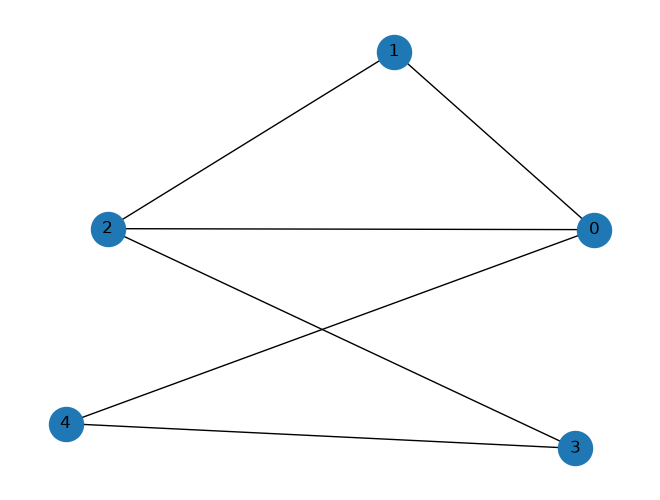

In [3]:
n_small = 5

graph = rx.PyGraph()
graph.add_nodes_from(np.arange(0, n_small, 1))
edge_list = [
    (0, 1, 1.0),
    (0, 2, 1.0),
    (0, 4, 1.0),
    (1, 2, 1.0),
    (2, 3, 1.0),
    (3, 4, 1.0),
]
graph.add_edges_from(edge_list)
draw_graph(graph, node_size=600, with_labels=True)

### Step 1: Map classical inputs to a quantum problem

Map the classical graph into quantum **circuits** and **operators**. As described in the [Background](#background), for unweighted max-cut the cost Hamiltonian reduces to $H_C = \sum_{(i,j) \in E} Z_i Z_j$, and QAOA uses a parametrized ansatz circuit to prepare candidate ground states of $H_C$.



#### Build the cost Hamiltonian

Convert the graph edges into Pauli $Z_iZ_j$ terms to construct $H_C$ (see [Background](#background) for the derivation).



In [4]:
def build_max_cut_paulis(
    graph: rx.PyGraph,
) -> list[tuple[str, list[int], float]]:
    """Convert graph edges to a list of ZZ Pauli terms.

    The returned list is in the sparse format expected by
    ``SparsePauliOp.from_sparse_list``: each element is
    ``(pauli_string, qubit_indices, coefficient)``.
    """
    pauli_list = []
    for edge in list(graph.edge_list()):
        weight = graph.get_edge_data(edge[0], edge[1])
        pauli_list.append(("ZZ", [edge[0], edge[1]], weight))
    return pauli_list


max_cut_paulis = build_max_cut_paulis(graph)
cost_hamiltonian = SparsePauliOp.from_sparse_list(max_cut_paulis, n_small)
print("Cost Function Hamiltonian:", cost_hamiltonian)

Cost Function Hamiltonian: SparsePauliOp(['IIIZZ', 'IIZIZ', 'ZIIIZ', 'IIZZI', 'IZZII', 'ZZIII'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j])


#### Build the QAOA ansatz circuit



Use `QAOAAnsatz` to construct the parametrized QAOA circuit from the cost Hamiltonian. Here we use `reps=2` (two QAOA layers, four parameters: $\beta_0, \beta_1, \gamma_0, \gamma_1$).



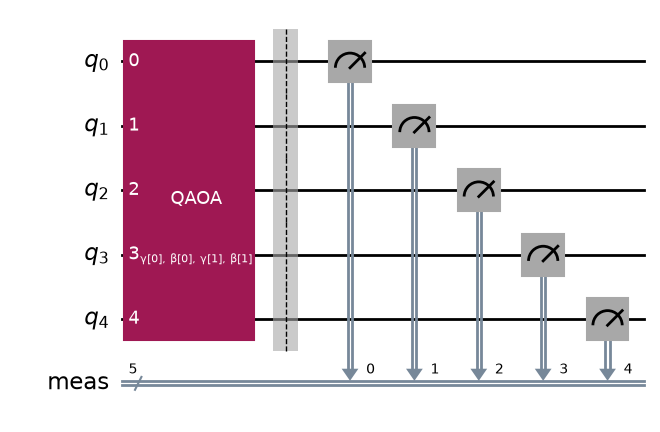

In [5]:
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=2)
circuit.measure_all()

circuit.draw("mpl")

In [5]:
circuit.parameters

ParameterView([ParameterVectorElement(β[0]), ParameterVectorElement(β[1]), ParameterVectorElement(γ[0]), ParameterVectorElement(γ[1])])

### Step 2: Optimize problem for quantum hardware execution



Transpile the abstract circuit into hardware-native instructions. This step handles qubit mapping, gate decomposition, routing, and error suppression. See the transpilation [documentation](/docs/guides/transpile) for more information.



In [6]:
service = QiskitRuntimeService()
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=127
)
print(backend)

# Create pass manager for transpilation. Level 3 is the most aggressive
# preset: slower to transpile, but produces shorter circuits that are
# more robust to hardware noise.
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)

candidate_circuit = pm.run(circuit)
candidate_circuit.draw("mpl", fold=False, idle_wires=False)

IBMInputValueError: 'No matching instances found for the following filters: .'

### Step 3: Execute using Qiskit primitives



The QAOA optimization loop runs inside a Quantum Compute [session](/docs/guides/execution-modes) to keep the device reserved across iterations. An Estimator evaluates $\langle H_C \rangle$ at each step, and a classical optimizer (COBYLA) updates the parameters until convergence.

![Illustration showing the behavior of Single job, Batch, and Session runtime modes.](https://quantum.cloud.ibm.com/docs/images/tutorials/quantum-approximate-optimization-algorithm/runtime-modes.avif)



Define initial parameters and run the optimization loop:



In [7]:
# QAOA doesn't prescribe principled default angles — any bounded choice
# works as a warm start for problems this small. beta and gamma are
# periodic (beta in [0, pi] and gamma in [0, 2*pi] modulo the underlying
# Pauli-rotation periods), and pi/2 and pi are just midpoints of those
# ranges. For harder problems you would typically warm start from known
# good angles or transfer parameters from smaller instances.
initial_gamma = np.pi
initial_beta = np.pi / 2
init_params = [initial_beta, initial_beta, initial_gamma, initial_gamma]

In [8]:
def cost_func_estimator(params, ansatz, hamiltonian, estimator):
    # transform the observable defined on virtual qubits to
    # an observable defined on all physical qubits
    isa_hamiltonian = hamiltonian.apply_layout(ansatz.layout)

    pub = (ansatz, isa_hamiltonian, params)
    job = estimator.run([pub])

    results = job.result()[0]
    cost = results.data.evs

    objective_func_vals.append(cost)

    return cost

In [9]:
objective_func_vals = []  # Global variable
with Session(backend=backend) as session:
    # If using qiskit-ibm-runtime<0.24.0, change `mode=` to `session=`
    estimator = Estimator(mode=session)
    estimator.options.default_shots = 1000

    # Set simple error suppression/mitigation options
    estimator.options.dynamical_decoupling.enable = True
    estimator.options.dynamical_decoupling.sequence_type = "XY4"
    estimator.options.twirling.enable_gates = True
    estimator.options.twirling.num_randomizations = "auto"
    estimator.options.environment.job_tags = ["TUT_QAOA"]

    result = minimize(
        cost_func_estimator,
        init_params,
        args=(candidate_circuit, cost_hamiltonian, estimator),
        method="COBYLA",
        tol=1e-2,
    )
    print(result)

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -2.0402211719947774
       x: [ 3.041e+00  1.212e+00  2.081e+00  4.471e+00]
    nfev: 36
   maxcv: 0.0


The optimizer was able to reduce the cost and find better parameters for the circuit.

A smoothly decreasing curve that plateaus is the signature of convergence. A noisy, non-monotonic curve usually indicates that something upstream needs attention; common causes are too few shots per evaluation (high estimator variance), poor initial parameters, or a circuit whose depth is dominated by hardware noise. COBYLA is derivative-free and fairly robust to moderate noise, but when the noise swamps the actual cost improvements per step, its linear-approximation model can no longer tell real descent from random jitter and the optimizer wanders.



In [10]:
plt.figure(figsize=(12, 6))
plt.plot(objective_func_vals)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

<Image src="/docs/images/tutorials/quantum-approximate-optimization-algorithm/extracted-outputs/e14ecc92-0.avif" alt="Output of the previous code cell" />

Assign the optimized parameters and sample the final distribution using the Sampler primitive.



In [11]:
optimized_circuit = candidate_circuit.assign_parameters(result.x)
optimized_circuit.draw("mpl", fold=False, idle_wires=False)

<Image src="/docs/images/tutorials/quantum-approximate-optimization-algorithm/extracted-outputs/2989e76e-4296-4dd8-b065-2b8fced064cf-0.avif" alt="Output of the previous code cell" />

In [12]:
# If using qiskit-ibm-runtime<0.24.0, change `mode=` to `backend=`
sampler = Sampler(mode=backend)
sampler.options.default_shots = 10000

# Set simple error suppression/mitigation options
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XY4"
sampler.options.twirling.enable_gates = True
sampler.options.twirling.num_randomizations = "auto"

sampler.options.environment.job_tags = ["TUT_QAOA"]

pub = (optimized_circuit,)
job = sampler.run([pub], shots=int(1e4))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()
shots = sum(counts_int.values())
final_distribution_int = {key: val / shots for key, val in counts_int.items()}
final_distribution_bin = {key: val / shots for key, val in counts_bin.items()}
print(final_distribution_int)

{18: 0.039, 5: 0.0665, 20: 0.0973, 29: 0.0063, 9: 0.0899, 13: 0.0379, 2: 0.0047, 1: 0.0153, 11: 0.0932, 14: 0.0327, 12: 0.0314, 25: 0.0193, 21: 0.0398, 6: 0.0224, 4: 0.0197, 10: 0.0387, 3: 0.0181, 26: 0.07, 17: 0.0327, 19: 0.0332, 22: 0.0914, 24: 0.007, 0: 0.0033, 8: 0.0066, 30: 0.0158, 28: 0.0169, 27: 0.0222, 16: 0.0073, 7: 0.0057, 23: 0.0062, 15: 0.0054, 31: 0.0041}


### Step 4: Post-process and return result in desired classical format

Extract the most likely bitstring from the sampled distribution. This represents the best cut found by QAOA.



In [13]:
# auxiliary functions to sample most likely bitstring
def to_bitstring(integer, num_bits):
    result = np.binary_repr(integer, width=num_bits)
    return [int(digit) for digit in result]


keys = list(final_distribution_int.keys())
values = list(final_distribution_int.values())
most_likely = keys[np.argmax(np.abs(values))]
most_likely_bitstring = to_bitstring(most_likely, len(graph))
most_likely_bitstring.reverse()

print("Result bitstring:", most_likely_bitstring)

Result bitstring: [0, 0, 1, 0, 1]


In [14]:
plt.rcParams.update({"font.size": 10})
final_bits = final_distribution_bin
values = np.abs(list(final_bits.values()))
top_4_values = sorted(values, reverse=True)[:4]
positions = []
for value in top_4_values:
    positions.append(np.where(values == value)[0])
fig = plt.figure(figsize=(11, 6))
ax = fig.add_subplot(1, 1, 1)
plt.xticks(rotation=45)
plt.title("Result Distribution")
plt.xlabel("Bitstrings (reversed)")
plt.ylabel("Probability")
ax.bar(list(final_bits.keys()), list(final_bits.values()), color="tab:grey")
for p in positions:
    ax.get_children()[int(p[0])].set_color("tab:purple")
plt.show()

<Image src="/docs/images/tutorials/quantum-approximate-optimization-algorithm/extracted-outputs/650875e9-adbc-43bd-9505-556be2566278-0.avif" alt="Output of the previous code cell" />

#### Visualize best cut

From the optimal bitstring, you can then visualize this cut on the original graph.



In [15]:
# auxiliary function to plot graphs
def plot_result(G, x):
    colors = ["tab:grey" if i == 0 else "tab:purple" for i in x]
    pos, _default_axes = rx.spring_layout(G), plt.axes(frameon=True)
    rx.visualization.mpl_draw(
        G, node_color=colors, node_size=100, alpha=0.8, pos=pos
    )


plot_result(graph, most_likely_bitstring)

<Image src="/docs/images/tutorials/quantum-approximate-optimization-algorithm/extracted-outputs/33135970-8bc4-4fb2-ab87-08726a432ce4-0.avif" alt="Output of the previous code cell" />

Now, calculate the value of the cut:



In [16]:
def evaluate_sample(x: Sequence[int], graph: rx.PyGraph) -> float:
    assert len(x) == len(
        list(graph.nodes())
    ), "The length of x must coincide with the number of nodes in the graph."
    return sum(
        x[u] * (1 - x[v]) + x[v] * (1 - x[u])
        for u, v in list(graph.edge_list())
    )


cut_value = evaluate_sample(most_likely_bitstring, graph)
print("The value of the cut is:", cut_value)

The value of the cut is: 5


For a graph this small, the true optimum is easy to brute-force, so you can double-check the results by comparing the QAOA result against the exact answer.



In [17]:
# Classical baseline: enumerate all 2**n_small bitstrings and take the best cut.
def brute_force_max_cut(graph: rx.PyGraph) -> tuple[int, list[int]]:
    n = len(list(graph.nodes()))
    best_cut = -1
    best_x: list[int] = []
    for i in range(2**n):
        x = [(i >> k) & 1 for k in range(n)]
        cut = evaluate_sample(x, graph)
        if cut > best_cut:
            best_cut = int(cut)
            best_x = x
    return best_cut, best_x


classical_best, classical_x = brute_force_max_cut(graph)
print(f"Classical optimum (brute force): {classical_best}")
print(f"QAOA cut value:                  {cut_value}")

Classical optimum (brute force): 5
QAOA cut value:                  5


## Large-scale hardware example

You have access to many devices with over 100 qubits on IBM Quantum Platform. Select one on which to solve max-cut on a 100-node weighted graph. This is a "utility-scale" problem. The workflow follows the same steps as above, applied to a much larger graph.



### End-to-end workflow at utility scale

All four steps are shown below, applied to the 100-node graph. The structure is the same as the small-scale walkthrough: map, transpile, execute, post-process — but with a larger problem and split across the four cells below for clarity.



In [ ]:
# Precomputed parity lookup table: _PARITY[b] = +1 if popcount(b) is even, else -1.
# We use this to vectorize expectation-value evaluation across all Pauli terms.
_PARITY = np.array(
    [-1 if bin(i).count("1") % 2 else 1 for i in range(256)],
    dtype=np.complex128,
)


def evaluate_sparse_pauli(state: int, observable: SparsePauliOp) -> complex:
    """Expectation value of a SparsePauliOp on a single computational-basis state.

    For a Z-only observable (which QAOA cost Hamiltonians are, after the
    QUBO-to-Hamiltonian mapping), the eigenvalue of each Pauli term on a
    computational-basis state is simply (-1)**popcount(z_mask AND state),
    i.e., the parity of the bitwise-AND of the term's Z-support and the
    measured bitstring.

    This routine packs the Z-support of every Pauli term into bytes, ANDs
    them against the measured state in a single vectorized op, and looks up
    the parity in _PARITY. For a 100-qubit / ~hundreds-of-terms Hamiltonian
    over 10_000 samples, this is dramatically faster than calling
    SparsePauliOp.expectation_value per sample.
    """
    packed_uint8 = np.packbits(observable.paulis.z, axis=1, bitorder="little")
    state_bytes = np.frombuffer(
        state.to_bytes(packed_uint8.shape[1], "little"), dtype=np.uint8
    )
    reduced = np.bitwise_xor.reduce(packed_uint8 & state_bytes, axis=1)
    return np.sum(observable.coeffs * _PARITY[reduced])


def best_solution(samples, hamiltonian):
    """Return the sampled bitstring (as int) with the lowest Hamiltonian cost."""
    min_cost = float("inf")
    min_sol = None
    for bit_str in samples.keys():
        candidate_sol = int(bit_str)
        fval = evaluate_sparse_pauli(candidate_sol, hamiltonian).real
        if fval <= min_cost:
            min_cost = fval
            min_sol = candidate_sol
    return min_sol


def _plot_cdf(objective_values: dict, ax, color):
    x_vals = sorted(objective_values.keys(), reverse=True)
    y_vals = np.cumsum([objective_values[x] for x in x_vals])
    ax.plot(x_vals, y_vals, color=color)


def plot_cdf(dist, ax, title):
    _plot_cdf(dist, ax, "C1")
    ax.vlines(min(list(dist.keys())), 0, 1, "C1", linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Objective function value")
    ax.set_ylabel("Cumulative distribution function")
    ax.grid(alpha=0.3)


def samples_to_objective_values(samples, hamiltonian):
    """Convert the samples to values of the objective function."""
    objective_values = defaultdict(float)
    for bit_str, prob in samples.items():
        candidate_sol = int(bit_str)
        fval = evaluate_sparse_pauli(candidate_sol, hamiltonian).real
        objective_values[fval] += prob
    return objective_values

**Step 1**: Build the graph, cost Hamiltonian, and ansatz.



In [19]:
# Step 1: build the 100-node graph, cost Hamiltonian, and QAOA ansatz.
n_large = 100
graph_100 = rx.PyGraph()
graph_100.add_nodes_from(np.arange(0, n_large, 1))
elist = []
for edge in backend.coupling_map:
    if edge[0] < n_large and edge[1] < n_large:
        elist.append((edge[0], edge[1], 1.0))
graph_100.add_edges_from(elist)

max_cut_paulis_100 = build_max_cut_paulis(graph_100)
cost_hamiltonian_100 = SparsePauliOp.from_sparse_list(
    max_cut_paulis_100, n_large
)

circuit_100 = QAOAAnsatz(cost_operator=cost_hamiltonian_100, reps=1)
circuit_100.measure_all()

**Step 2**: Transpile for the selected hardware backend.



In [20]:
# Step 2: transpile for hardware.
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
candidate_circuit_100 = pm.run(circuit_100)

**Step 3**: Run the QAOA optimization loop inside a session, then sample.



In [21]:
# Step 3: run the QAOA optimization loop on the device, then sample the
# final distribution with the optimized parameters.
initial_gamma = np.pi
initial_beta = np.pi / 2
init_params = [initial_beta, initial_gamma]

objective_func_vals = []  # Global variable
with Session(backend=backend) as session:
    estimator = Estimator(mode=session)
    estimator.options.default_shots = 1000

    # Set simple error suppression/mitigation options
    estimator.options.dynamical_decoupling.enable = True
    estimator.options.dynamical_decoupling.sequence_type = "XY4"
    estimator.options.twirling.enable_gates = True
    estimator.options.twirling.num_randomizations = "auto"
    estimator.options.environment.job_tags = ["TUT_QAOA"]

    result = minimize(
        cost_func_estimator,
        init_params,
        args=(candidate_circuit_100, cost_hamiltonian_100, estimator),
        method="COBYLA",
    )
    print(result)

# Assign optimal parameters and sample the final distribution.
optimized_circuit_100 = candidate_circuit_100.assign_parameters(result.x)

sampler = Sampler(mode=backend)
sampler.options.default_shots = 10000

# Set simple error suppression/mitigation options
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XY4"
sampler.options.twirling.enable_gates = True
sampler.options.twirling.num_randomizations = "auto"

# Add a unique tag to the job execution
sampler.options.environment.job_tags = ["TUT_QAOA"]

pub = (optimized_circuit_100,)
job = sampler.run([pub], shots=int(1e4))

counts_int = job.result()[0].data.meas.get_int_counts()
shots = sum(counts_int.values())
final_distribution_100_int = {
    key: val / shots for key, val in counts_int.items()
}

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -17.172689238986344
       x: [ 2.574e+00  4.166e+00]
    nfev: 28
   maxcv: 0.0


**Step 4**: Post-process the sampled distribution to extract the best cut.



In [22]:
# Step 4: find the best-cost sample and evaluate its cut value.
best_sol_100 = best_solution(final_distribution_100_int, cost_hamiltonian_100)
best_sol_bitstring_100 = to_bitstring(int(best_sol_100), len(graph_100))
best_sol_bitstring_100.reverse()

print("Result bitstring:", best_sol_bitstring_100)

cut_value_100 = evaluate_sample(best_sol_bitstring_100, graph_100)
print("The value of the cut is:", cut_value_100)

Result bitstring: [1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0]
The value of the cut is: 156


Check that the cost minimized in the optimization loop has converged, and visualize results.



In [23]:
# Plot convergence
plt.figure(figsize=(12, 6))
plt.plot(objective_func_vals)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

# Visualize the cut
plot_result(graph_100, best_sol_bitstring_100)

# Plot cumulative distribution function
result_dist = samples_to_objective_values(
    final_distribution_100_int, cost_hamiltonian_100
)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plot_cdf(result_dist, ax, backend.name)

<Image src="/docs/images/tutorials/quantum-approximate-optimization-algorithm/extracted-outputs/large-scale-viz-0.avif" alt="Output of the previous code cell" />

<Image src="/docs/images/tutorials/quantum-approximate-optimization-algorithm/extracted-outputs/large-scale-viz-1.avif" alt="Output of the previous code cell" />

<Image src="/docs/images/tutorials/quantum-approximate-optimization-algorithm/extracted-outputs/large-scale-viz-2.avif" alt="Output of the previous code cell" />

## Next steps

If you found this work interesting, you might be interested in the following material:

<Admonition type="tip" title="Recommendations">
  * [Advanced techniques for QAOA](/docs/tutorials/advanced-techniques-for-qaoa) — explores advanced strategies for improving QAOA performance
  * [Multi-objective optimization challenge](https://github.com/qiskit-community/qdc-challenges-2025/blob/main/challenges/Track_B/qmoo/qmoo_qdc25.ipynb) — put your skills to the test with this community challenge on multi-objective quantum optimization
  * [Transpilation documentation](/docs/guides/transpile) for fine-tuning circuit optimization
  * [Error suppression and mitigation](/docs/guides/error-mitigation-and-suppression-techniques) for improving hardware results
</Admonition>



© IBM Corp., 2017-2026